# Week 1, Day 1: Data Acquisition & Exploration
**EMA Crossover ML Project**

## Goals for Today (2 hours):
- ✅ Fetch labeled signals from Supabase (500+ records)
- ✅ Load data into pandas, check shape and dtypes
- ✅ Initial exploration: `.info()`, `.describe()`, `.head()`
- ✅ Identify missing values, outliers, data types
- ✅ **Deliverable:** Jupyter notebook with data loaded and explored

## 1. Setup & Imports

In [ ]:
# Install required packages (run once)
%pip install pandas numpy matplotlib seaborn requests python-dotenv


In [ ]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from dotenv import load_dotenv

import warnings
warnings.filterwarnings('ignore')
load_dotenv()

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print('Imports successful!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')


Imports successful!
Pandas version: 2.3.3
NumPy version: 2.4.3


## 2. Connect to Supabase & Fetch Data

In [2]:
# Load Supabase credentials from .env
SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_KEY')

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError('Missing SUPABASE_URL or SUPABASE_KEY in your .env file')

headers = {
    'apikey': SUPABASE_KEY,
    'Authorization': f'Bearer {SUPABASE_KEY}',
}

print('Supabase credentials loaded from .env')


Supabase credentials loaded from .env


In [3]:
# Fetch all analyzed signals from Supabase REST API using pagination
print('Fetching data from Supabase...')

try:
    batch_size = 1000
    offset = 0
    all_rows = []

    while True:
        response = requests.get(
            f'{SUPABASE_URL}/rest/v1/signals',
            headers={**headers, 'Range-Unit': 'items', 'Range': f'{offset}-{offset + batch_size - 1}'},
            params={'select': '*', 'status': 'eq.analyzed', 'order': 'checked_at_utc.asc'},
            timeout=30,
        )
        response.raise_for_status()

        batch = response.json()
        if not batch:
            break

        all_rows.extend(batch)
        print(f'Fetched {len(all_rows):,} rows so far...')

        if len(batch) < batch_size:
            break

        offset += batch_size

    df = pd.DataFrame(all_rows)

    print('Data fetched successfully!')
    print(f'Total records: {len(df):,}')

except Exception as e:
    print(f'Error fetching data: {e}')
    df = None


Fetching data from Supabase...
Fetched 1,000 rows so far...
Fetched 2,000 rows so far...
Fetched 3,000 rows so far...
Fetched 4,000 rows so far...
Fetched 5,000 rows so far...
Fetched 5,301 rows so far...
Data fetched successfully!
Total records: 5,301


## 3. Initial Data Inspection

In [4]:
# Check if data loaded successfully
if df is not None and len(df) > 0:
    print('DATA LOADED SUCCESSFULLY!\n')
    print(f'Shape: {df.shape}')
    print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
else:
    print('No data loaded. Check your .env file and Supabase access.')


DATA LOADED SUCCESSFULLY!

Shape: (5271, 48)
Rows: 5271 | Columns: 48


In [5]:
# Display first few rows
print("First 5 rows of data:\n")
df.head()

First 5 rows of data:



,id,checked_at_utc,symbol,signal,price,signal_gap_hours,prev_signal,ema_fast_ltf,ema_slow_ltf,ema_fast_slope,ema_slow_slope,ema_separation,price_above_both_emas,crossover_candle_strength,adx_ltf,adx_slope,adx_4h,macd_histogram_ltf,macd_histogram_4h,htf_4h_bias,htf_1d_bias,ema_separation_4h,rsi_4h,rsi_ltf,roc_ltf,atr_ltf,atr_pct,bb_width_ltf,price_to_atr,volume_ratio,volume_trend,crossover_volume_ratio,fear_greed_index,btc_trend_bias,hour_of_day,day_of_week,swing_high,swing_low,atr_stop_distance,max_price_after,min_price_after,max_move_up_pct,max_move_down_pct,time_of_max_price,time_of_min_price,candles_to_max_price,candles_to_min_price,status
0,1,2025-10-03T06:30:00+00:00,XRPUSDT,LONG,3.0314,9.32,SHORT,3.024908,3.024383,0.0537,0.0332,0.0174,True,0.0543,15.35,-0.72,32.78,0.001192,0.010259,True,True,0.9852,64.76,54.72,0.2016,0.010133,0.3343,0.8576,299.16,1.0062,-0.8964,1.0062,50,True,6,4,3.035,3.0136,0.015200,3.0350,3.0131,0.1188,0.6037,2025-10-03T06:30:00+00:00,2025-10-03T06:45:00+00:00,0,1,analyzed
1,2,2025-10-03T07:15:00+00:00,XRPUSDT,SHORT,3.0206,0.00,LONG,3.023798,3.023829,-0.0264,-0.0153,-0.0010,False,0.4370,14.41,-0.83,32.78,0.000436,0.010259,True,True,0.9852,64.76,46.91,-0.0695,0.010762,0.3563,0.5766,280.68,1.3071,2.1192,1.3071,50,True,7,4,3.035,3.0131,0.016142,3.0328,3.0189,0.4039,0.0563,2025-10-03T07:15:00+00:00,2025-10-03T07:30:00+00:00,0,1,analyzed
2,3,2025-10-03T07:30:00+00:00,XRPUSDT,LONG,3.0246,0.00,SHORT,3.023958,3.023925,0.0053,0.0032,0.0011,True,0.1466,13.68,-0.73,32.78,0.000452,0.010259,True,True,0.9852,64.76,49.93,0.1059,0.010822,0.3578,0.5085,279.50,1.6063,2.8898,1.6063,50,True,7,4,3.035,3.0131,0.016232,3.0582,3.0189,1.1109,0.1885,2025-10-03T08:45:00+00:00,2025-10-03T07:30:00+00:00,5,0,analyzed
3,985,2025-10-03T09:15:00+00:00,BTCUSDT,LONG,120291.2600,25.23,LONG,119951.649884,119933.052484,0.0708,0.0427,0.0155,True,0.1705,21.05,-1.02,57.71,53.247772,138.138157,True,True,0.8579,74.70,60.90,0.3498,217.361763,0.1807,0.6121,553.42,1.7411,7.8538,1.7411,50,True,9,4,120365.350,119248.3000,326.042644,123894.9900,119881.2400,2.9958,0.3409,2025-10-03T16:30:00+00:00,2025-10-03T14:15:00+00:00,29,20,analyzed
4,1963,2025-10-03T09:30:00+00:00,SOLUSDT,LONG,230.8400,25.55,SHORT,230.553295,230.536254,0.0311,0.0188,0.0074,True,0.9296,24.89,-1.08,33.53,0.225555,1.034962,True,True,1.5411,67.96,50.27,0.8960,1.102865,0.4778,1.7774,209.31,2.4880,9.4521,2.4880,50,True,9,4,231.790,227.7600,1.654297,231.7900,229.5700,0.4115,0.5502,2025-10-03T09:30:00+00:00,2025-10-03T11:15:00+00:00,0,7,analyzed


In [6]:
# Display last few rows
print("Last 5 rows of data:\n")
df.tail()

Last 5 rows of data:



,id,checked_at_utc,symbol,signal,price,signal_gap_hours,prev_signal,ema_fast_ltf,ema_slow_ltf,ema_fast_slope,ema_slow_slope,ema_separation,price_above_both_emas,crossover_candle_strength,adx_ltf,adx_slope,adx_4h,macd_histogram_ltf,macd_histogram_4h,htf_4h_bias,htf_1d_bias,ema_separation_4h,rsi_4h,rsi_ltf,roc_ltf,atr_ltf,atr_pct,bb_width_ltf,price_to_atr,volume_ratio,volume_trend,crossover_volume_ratio,fear_greed_index,btc_trend_bias,hour_of_day,day_of_week,swing_high,swing_low,atr_stop_distance,max_price_after,min_price_after,max_move_up_pct,max_move_down_pct,time_of_max_price,time_of_min_price,candles_to_max_price,candles_to_min_price,status
5266,6129,2026-04-20T14:30:00+00:00,ETHUSDT,SHORT,2302.61000,0.0,LONG,2308.961958,2309.023726,-0.0687,-0.0397,-0.0027,False,0.8068,27.55,-1.06,17.11,-1.977370,-7.342445,False,True,-0.4401,46.98,47.37,-0.5610,12.394920,0.5383,0.8900,185.77,1.4684,4.4729,1.4684,50,False,14,0,2326.36000,2295.41000,18.592379,2319.00000,2278.38000,0.7118,1.0523,2026-04-20T15:15:00+00:00,2026-04-20T15:00:00+00:00,3,2,analyzed
5267,6093,2026-04-20T15:00:00+00:00,SOLUSDT,SHORT,84.84000,0.0,LONG,85.107350,85.121345,-0.0785,-0.0472,-0.0164,False,0.7170,23.40,-1.38,19.30,-0.065228,-0.219212,False,True,-0.3615,50.16,45.72,-0.5626,0.447287,0.5272,0.8691,189.68,1.4233,3.8161,1.4233,50,False,15,0,85.81000,84.42000,0.670930,85.77000,84.42000,1.0962,0.4950,2026-04-20T15:15:00+00:00,2026-04-20T15:00:00+00:00,1,0,analyzed
5268,6130,2026-04-20T15:45:00+00:00,ETHUSDT,LONG,2313.91000,0.0,SHORT,2307.706046,2307.612962,0.0673,0.0390,0.0040,True,0.2158,23.57,-0.51,17.11,-0.719783,-7.342445,False,True,-0.4401,46.98,54.45,0.0575,13.769030,0.5951,1.3238,168.05,0.9762,3.5915,0.9762,50,False,15,0,2321.98000,2278.38000,20.653544,2315.01000,2300.00000,0.0475,0.6011,2026-04-20T16:00:00+00:00,2026-04-20T16:15:00+00:00,1,2,analyzed
5269,6131,2026-04-20T16:15:00+00:00,ETHUSDT,SHORT,2303.93000,0.0,LONG,2307.007470,2307.201487,-0.0333,-0.0203,-0.0084,False,0.9676,22.00,-1.14,16.12,-0.850944,-4.303799,False,True,-0.3191,50.87,48.86,0.1739,13.013143,0.5648,1.3351,177.05,0.4740,0.1761,0.4740,50,False,16,0,2321.98000,2278.38000,19.519714,2322.40000,2297.97000,0.8017,0.2587,2026-04-20T17:15:00+00:00,2026-04-20T17:00:00+00:00,4,3,analyzed
5270,6161,2026-04-20T16:30:00+00:00,DOGEUSDT,SHORT,0.09465,0.0,LONG,0.094759,0.094762,-0.0286,-0.0169,-0.0040,False,0.4444,14.23,-0.74,18.70,-0.000043,-0.000123,False,True,-0.2869,50.67,49.07,-0.4418,0.000433,0.4573,0.9898,218.68,0.4515,-6.6121,0.4515,50,False,16,0,0.09541,0.09407,0.000649,0.09524,0.09437,0.6233,0.2958,2026-04-20T17:15:00+00:00,2026-04-20T16:30:00+00:00,3,0,analyzed


## 4. Data Types & Structure (`.info()`)

In [8]:
# Get detailed info about the DataFrame
print("DataFrame Information:\n")
df.info()

DataFrame Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5271 entries, 0 to 5270
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         5271 non-null   int64  
 1   checked_at_utc             5271 non-null   object 
 2   symbol                     5271 non-null   object 
 3   signal                     5271 non-null   object 
 4   price                      5271 non-null   float64
 5   signal_gap_hours           5256 non-null   float64
 6   prev_signal                5256 non-null   object 
 7   ema_fast_ltf               5271 non-null   float64
 8   ema_slow_ltf               5271 non-null   float64
 9   ema_fast_slope             5271 non-null   float64
 10  ema_slow_slope             5271 non-null   float64
 11  ema_separation             5271 non-null   float64
 12  price_above_both_emas      5271 non-null   bool   
 13  crossover_candle_strengt

In [4]:
# Count data types
print("\nColumn types breakdown:")
print(df.dtypes.value_counts())
print("\n" + "="*50)

# Separate columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"\n📊 Numeric columns: {len(numeric_cols)}")
print(f"📝 Object (string) columns: {len(object_cols)}")
print(f"📅 Datetime columns: {len(datetime_cols)}")
print(f"✓ Boolean columns: {len(bool_cols)}")


Column types breakdown:
float64    31
object      7
int64       6
bool        4
Name: count, dtype: int64


📊 Numeric columns: 37
📝 Object (string) columns: 7
📅 Datetime columns: 0
✓ Boolean columns: 4


## 5. Fix Data Types

In [10]:
# Convert datetime columns to proper datetime format
datetime_columns = ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']

for col in datetime_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True)
        print(f"✅ Converted {col} to datetime")

# Sort by time (oldest to newest) - CRITICAL for time-series ML
df = df.sort_values('checked_at_utc').reset_index(drop=True)
print("\n✅ Data sorted by time (oldest → newest)")

print(f"\nDate range: {df['checked_at_utc'].min()} to {df['checked_at_utc'].max()}")

ValueError: time data "2026-04-06T16:33:54.909309+00:00" doesn't match format "%Y-%m-%dT%H:%M:%S%z", at position 4953. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## 6. Statistical Summary (`.describe()`)

In [11]:
# Get statistical summary of numeric columns
print("Statistical Summary of All Numeric Features:\n")
df.describe().T  # Transpose for better readability

Statistical Summary of All Numeric Features:



,count,mean,std,min,25%,50%,75%,max
id,5271.0,2670.433504,1583.553926,1.000000,1318.500000,2636.000000,3953.500000,6161.000000
price,5271.0,18082.185650,35199.681189,0.089060,1.448000,129.060000,3292.890000,125057.200000
signal_gap_hours,5256.0,0.158693,5.794061,0.000000,0.000000,0.000000,0.000000,240.890000
ema_fast_ltf,5271.0,18083.459875,35202.994164,0.088794,1.449673,128.506361,3296.121641,125268.458096
ema_slow_ltf,5271.0,18083.565846,35203.275251,0.088767,1.449798,128.511335,3296.116745,125279.032882
ema_fast_slope,5271.0,0.000749,0.135994,-1.169300,-0.071450,0.001300,0.069400,1.206800
ema_slow_slope,5271.0,0.000410,0.081947,-0.713300,-0.043000,0.000800,0.041750,0.749500
ema_separation,5271.0,-0.000017,0.032965,-0.311000,-0.011900,0.000000,0.011300,0.417700
crossover_candle_strength,5271.0,0.507556,0.353769,0.000000,0.159150,0.514500,0.862150,1.000000
adx_ltf,5271.0,20.809981,8.038083,6.400000,14.930000,19.200000,24.885000,63.390000


In [5]:
# Categorical/String columns summary
print("\nCategorical Columns Summary:\n")
for col in object_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


Categorical Columns Summary:


checked_at_utc:
checked_at_utc
2026-04-19T11:15:00+00:00    5
2026-03-01T14:00:00+00:00    5
2026-03-01T16:45:00+00:00    5
2025-11-05T02:30:00+00:00    5
2025-11-21T20:15:00+00:00    5
                            ..
2025-10-03T13:45:00+00:00    1
2025-10-03T12:30:00+00:00    1
2025-10-03T12:15:00+00:00    1
2025-10-03T11:00:00+00:00    1
2025-10-03T10:30:00+00:00    1
Name: count, Length: 4046, dtype: int64
----------------------------------------

symbol:
symbol
ETHUSDT     1120
BTCUSDT     1066
SOLUSDT     1058
XRPUSDT     1050
DOGEUSDT    1007
Name: count, dtype: int64
----------------------------------------

signal:
signal
LONG     2656
SHORT    2645
Name: count, dtype: int64
----------------------------------------

prev_signal:
prev_signal
SHORT    2643
LONG     2642
Name: count, dtype: int64
----------------------------------------

time_of_max_price:
time_of_max_price
2026-03-20T08:00:00+00:00    9
2026-03-01T14:00:00+00:00    8
2026-02-08T23:0

## 7. Missing Values Analysis

In [10]:
# Count missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("⚠️ Columns with Missing Values:\n")
    print(missing_df)
    print(f"\nTotal columns with missing data: {len(missing_df)}")
else:
    print("✅ No missing values found! Clean dataset.")

⚠️ Columns with Missing Values:

                  Missing_Count  Missing_Percentage
prev_signal                  16             0.30183
signal_gap_hours             16             0.30183

Total columns with missing data: 2


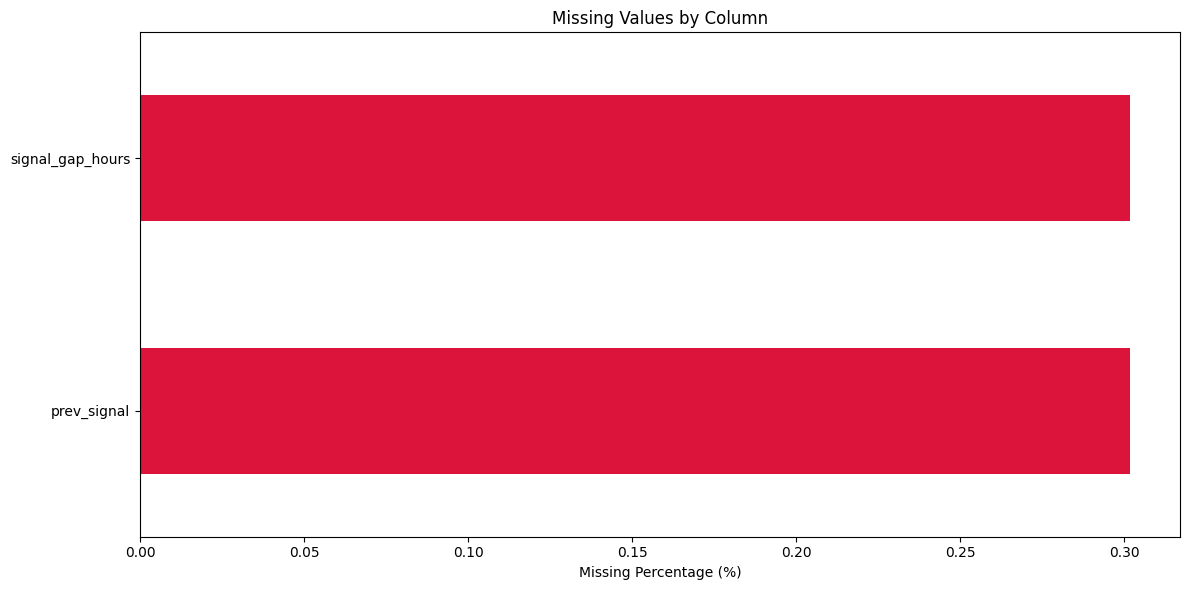

In [11]:
# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    missing_df['Missing_Percentage'].plot(kind='barh', color='crimson')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize.")

## 8. Outlier Detection (Initial)

In [12]:
# Define the 35 ML features (excluding metadata and labels)
feature_cols = [
    # Signal Context
    'signal_gap_hours',
    # EMA Indicators (7)
    'ema_fast_ltf', 'ema_slow_ltf', 'ema_fast_slope', 'ema_slow_slope',
    'ema_separation', 'price_above_both_emas', 'crossover_candle_strength',
    # Trend Strength (5)
    'adx_ltf', 'adx_slope', 'adx_4h', 'macd_histogram_ltf', 'macd_histogram_4h',
    # Higher Timeframe Alignment (4)
    'htf_4h_bias', 'htf_1d_bias', 'ema_separation_4h', 'rsi_4h',
    # Momentum (2)
    'rsi_ltf', 'roc_ltf',
    # Volatility (4)
    'atr_ltf', 'atr_pct', 'bb_width_ltf', 'price_to_atr',
    # Volume (3)
    'volume_ratio', 'volume_trend', 'crossover_volume_ratio',
    # Market Context (4)
    'fear_greed_index', 'btc_trend_bias', 'hour_of_day', 'day_of_week',
    # Trade Management (3)
    'swing_high', 'swing_low', 'atr_stop_distance'
]

# Filter to only existing columns
existing_features = [col for col in feature_cols if col in df.columns]
print(f"Found {len(existing_features)} out of 35 feature columns\n")

if len(existing_features) < len(feature_cols):
    missing_features = set(feature_cols) - set(existing_features)
    print(f"⚠️ Missing features: {missing_features}")

Found 33 out of 35 feature columns



In [13]:
# Check for extreme outliers using IQR method
print("Outlier Detection (IQR Method):\n")

numeric_features = [col for col in existing_features if col in numeric_cols]
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # 3*IQR for extreme outliers
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df)) * 100
    
    if outliers > 0:
        outlier_summary.append({
            'Feature': col,
            'Outliers': outliers,
            'Percentage': f"{outlier_pct:.2f}%",
            'Min': df[col].min(),
            'Max': df[col].max()
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("✅ No extreme outliers detected!")

Outlier Detection (IQR Method):

               Feature  Outliers Percentage          Min           Max
     macd_histogram_4h      1956     36.90% -1175.550688    732.533658
    macd_histogram_ltf      1939     36.58%  -260.130759    422.515262
          ema_fast_ltf      1066     20.11%     0.088794 125268.458096
             swing_low      1066     20.11%     0.080010 125032.010000
            swing_high      1066     20.11%     0.089530 126199.630000
          ema_slow_ltf      1066     20.11%     0.088767 125279.032882
               atr_ltf      1050     19.81%     0.000156   1186.481733
     atr_stop_distance      1050     19.81%     0.000234   1779.722600
          volume_ratio       160      3.02%     0.037000     13.087500
crossover_volume_ratio       160      3.02%     0.037000     13.087500
          volume_trend       159      3.00%   -56.028600    180.251400
        ema_separation       152      2.87%    -0.311000      0.417700
          price_to_atr        82      1.55% 

## 9. Label Distribution Analysis

In [14]:
# Analyze the label columns (outcome data)
label_cols = ['max_price_after', 'min_price_after', 'max_move_up_pct', 
              'max_move_down_pct', 'candles_to_max_price', 'candles_to_min_price']

existing_labels = [col for col in label_cols if col in df.columns]

print("Label Columns Summary:\n")
print(df[existing_labels].describe().T)

Label Columns Summary:

                       count          mean           std      min     25%  \
max_price_after       5301.0  18179.031995  35394.258731  0.08953  1.4661   
min_price_after       5301.0  17917.964142  34905.728765  0.08001  1.4358   
max_move_up_pct       5301.0      0.978550      1.460464  0.00000  0.2751   
max_move_down_pct     5301.0      1.098474      1.934076 -0.03390  0.2901   
candles_to_max_price  5301.0      7.512733     12.029872  0.00000  1.0000   
candles_to_min_price  5301.0      8.127712     13.882462  0.00000  1.0000   

                           50%        75%          max  
max_price_after       130.3500  3314.9000  126199.6300  
min_price_after       127.5100  3245.4500  123735.7300  
max_move_up_pct         0.5502     1.0957      25.4224  
max_move_down_pct       0.5983     1.1999      61.5416  
candles_to_max_price    3.0000     9.0000     185.0000  
candles_to_min_price    4.0000    10.0000     394.0000  


NameError: name 'existing_labels' is not defined

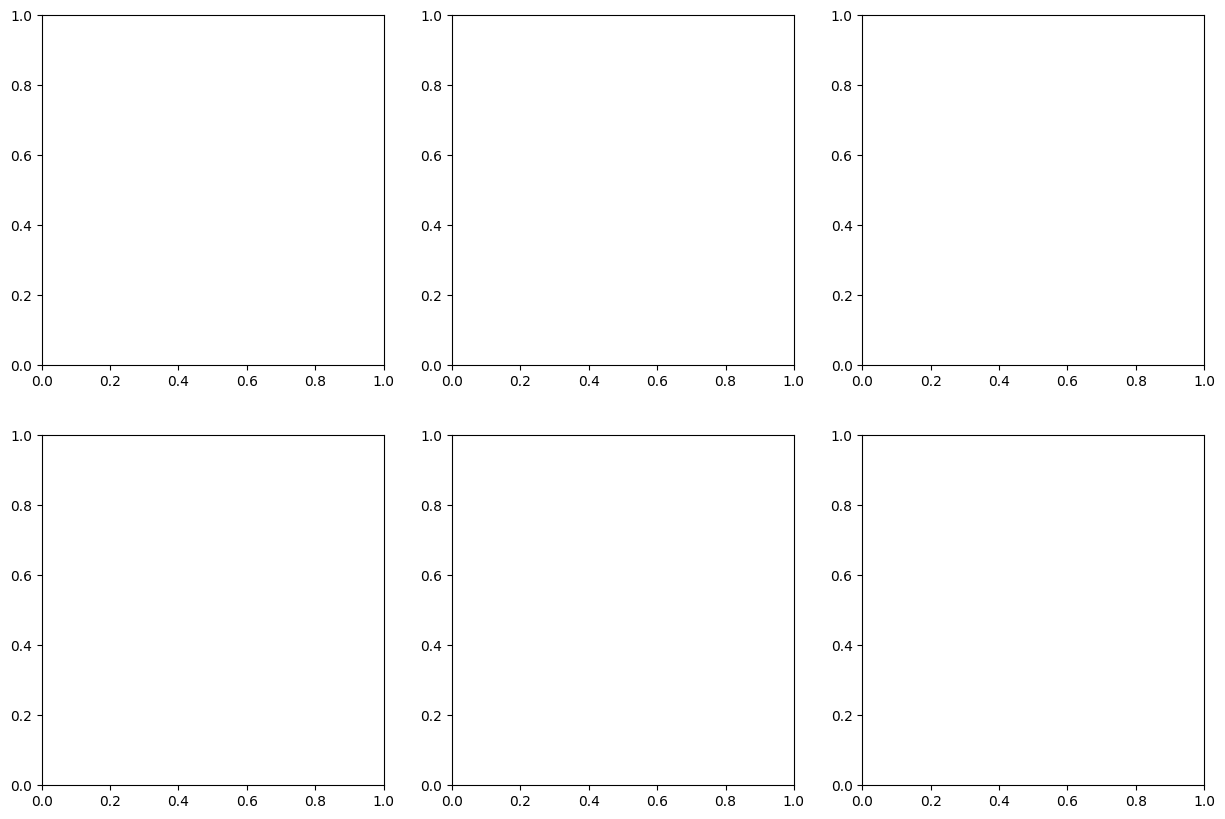

In [9]:
# Visualize label distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(existing_labels):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black')
        axes[idx].set_title(col)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Label Columns', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 10. Signal Distribution

In [6]:
# Count signals by type
print("Signal Type Distribution:\n")
signal_counts = df['signal'].value_counts()
print(signal_counts)
print(f"\nLONG signals: {signal_counts.get('LONG', 0)} ({signal_counts.get('LONG', 0)/len(df)*100:.1f}%)")
print(f"SHORT signals: {signal_counts.get('SHORT', 0)} ({signal_counts.get('SHORT', 0)/len(df)*100:.1f}%)")

Signal Type Distribution:

signal
LONG     2656
SHORT    2645
Name: count, dtype: int64

LONG signals: 2656 (50.1%)
SHORT signals: 2645 (49.9%)



Signals by Trading Pair:

symbol
ETHUSDT     1120
BTCUSDT     1066
SOLUSDT     1058
XRPUSDT     1050
DOGEUSDT    1007
Name: count, dtype: int64


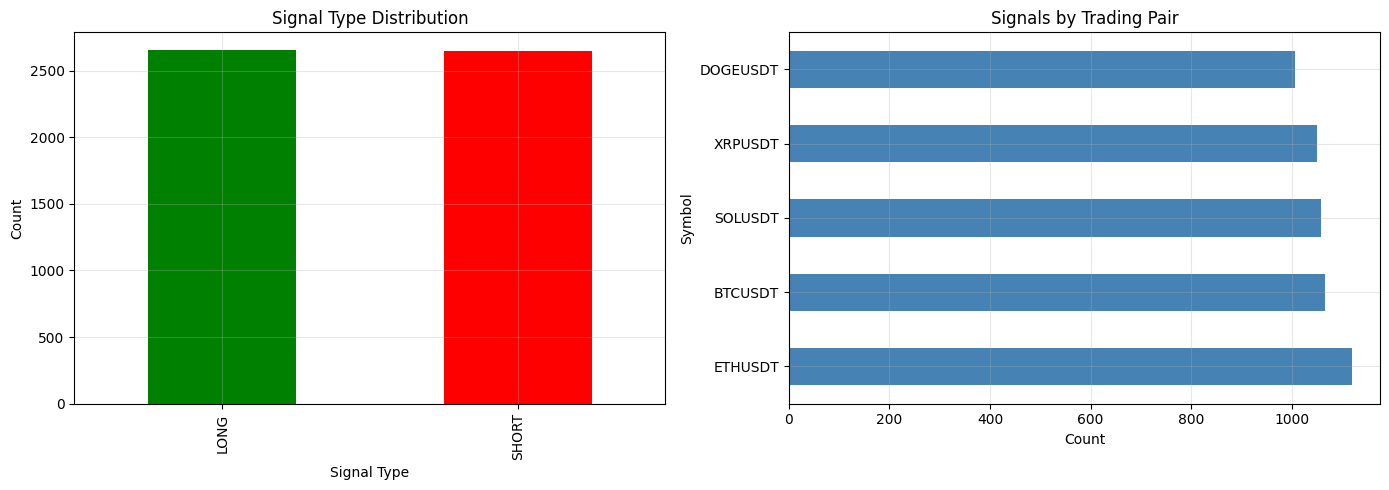

In [7]:
# Signals by symbol
print("\nSignals by Trading Pair:\n")
symbol_counts = df['symbol'].value_counts()
print(symbol_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Signal type
signal_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Signal Type Distribution')
axes[0].set_xlabel('Signal Type')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Symbol distribution
symbol_counts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Signals by Trading Pair')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Symbol')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Summary Report

In [8]:
print("="*60)
print("📊 DATA EXPLORATION SUMMARY REPORT")
print("="*60)
print(f"\n✅ Total Records: {len(df):,}")
print(f"✅ Total Features: {df.shape[1]}")
print(f"✅ Numeric Features: {len(numeric_cols)}")
print(f"✅ Boolean Features: {len(bool_cols)}")
print(f"✅ Categorical Features: {len(object_cols)}")
print(f"✅ Datetime Features: {len(datetime_cols)}")

print(f"\n📅 Date Range:")
print(f"   From: {df['checked_at_utc'].min()}")
print(f"   To:   {df['checked_at_utc'].max()}")
print(f"   Span: {(df['checked_at_utc'].max() - df['checked_at_utc'].min()).days} days")

print(f"\n🎯 Signals:")
print(f"   LONG signals:  {signal_counts.get('LONG', 0):,}")
print(f"   SHORT signals: {signal_counts.get('SHORT', 0):,}")

print(f"\n💹 Trading Pairs: {df['symbol'].nunique()}")
print(f"   {', '.join(df['symbol'].unique())}")

if len(missing_df) > 0:
    print(f"\n⚠️ Missing Values: {len(missing_df)} columns have missing data")
else:
    print(f"\n✅ Missing Values: None! Clean dataset.")

if outlier_summary:
    print(f"\n⚠️ Outliers Detected: {len(outlier_summary)} features have extreme values")
else:
    print(f"\n✅ Outliers: No extreme outliers detected")

print("\n" + "="*60)
print("🎉 DAY 1 COMPLETE - Data Successfully Loaded & Explored!")
print("="*60)
print("\nNext Steps (Day 2):")
print("  1. Handle missing values (if any)")
print("  2. Remove duplicates (if any)")
print("  3. Feature validation & corrections")
print("  4. Save cleaned dataset for modeling")

📊 DATA EXPLORATION SUMMARY REPORT

✅ Total Records: 5,301
✅ Total Features: 48
✅ Numeric Features: 37
✅ Boolean Features: 4
✅ Categorical Features: 7
✅ Datetime Features: 0

📅 Date Range:
   From: 2025-10-03T06:30:00+00:00
   To:   2026-04-21T19:00:00+00:00


TypeError: unsupported operand type(s) for -: 'str' and 'str'

## 12. Save Checkpoint (Optional)

In [ ]:
# Save the raw data for future use
# df.to_csv('data_raw.csv', index=False)
# print("✅ Raw data saved to 'data_raw.csv'")

# Or save as pickle (preserves data types)
# df.to_pickle('data_raw.pkl')
# print("✅ Raw data saved to 'data_raw.pkl'")

---
## ✅ Day 1 Checklist:
- [x] Fetch labeled signals from Supabase (500+ records)
- [x] Load data into pandas, check shape and dtypes
- [x] Initial exploration: `.info()`, `.describe()`, `.head()`
- [x] Identify missing values, outliers, data types
- [x] **Deliverable:** Jupyter notebook with data loaded and explored

**Next Session:** Week 1, Day 2 - Data Cleaning